# Hotel Booking Cancellation Prediction
  The main goal of this project is to understand hotel booking data and use machine learning to predict whether a customer will cancel their booking or not.

## 1.Project Introduction
    1.1 Problem Statement:
        Hotel bookings are sometimes cancelled by customers.These cancellations can cause problems for hotels, such as empty rooms ans loss of revenue. So, we want to understand the booking data and find the reasons behind cancellations.
    
    1.2 Business Objective:
        The objective is to help hotels identify bookings that are more likely to be cancelled. This can help them manage rooms and booking more effectively.
        
    1.3 Project Goal: 
        The goal of this project is to analyze hotel booking data and build a machine learning model that can predict whether a booking will be cancelled or not

## 2.Import Libraries

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

## 3.Load Dataset

In [2]:
# 3.1 Read Dataset
df = pd.read_csv("../data/hotel_bookings.csv")

In [3]:
#3.2 Display first 5 rows
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 4 Dataset Understanding

In [4]:
#4.1 Dataset shape 
df.shape

(119390, 32)

In [5]:
#4.2 Column Names 
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [6]:
#4.3 Data types
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [7]:
# 4.4 Missing values 
df.isnull().sum()

hotel                                  0
is_canceled                            0
lead_time                              0
arrival_date_year                      0
arrival_date_month                     0
arrival_date_week_number               0
arrival_date_day_of_month              0
stays_in_weekend_nights                0
stays_in_week_nights                   0
adults                                 0
children                               4
babies                                 0
meal                                   0
country                              488
market_segment                         0
distribution_channel                   0
is_repeated_guest                      0
previous_cancellations                 0
previous_bookings_not_canceled         0
reserved_room_type                     0
assigned_room_type                     0
booking_changes                        0
deposit_type                           0
agent                              16340
company         

In [8]:
# 4.5 Duplicate values 
df.duplicated().sum()

np.int64(31994)

In [9]:
# 4.6 Target variable distribution
df["is_canceled"].value_counts()

is_canceled
0    75166
1    44224
Name: count, dtype: int64

In [10]:
#4.7 Statistical summary
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


- The dataset contains 119,390 bookings.
- Around 37% of bookings were cancelled.
- The average booking was made around 104 days before arrival.
- Some columns contain missing values, such as children, country, agent, and company.
- Some coloumns have unusual values that need to be checked during the data-cleaning process.

# 5. Data Cleaning


### 5.1 Handling missing values
    found missing values in four coloumns, children, country, agent, company




In [11]:
# children:- children is a count, so it should be a whole number. The median is 0, so we will replace the 4 missing values with 0.
    
df['children'] = df['children'].fillna(0)

In [12]:
# country :- We use Unknown because we dont know the customers country, so we dont want to guess. 
df['country'] = df['country'].fillna("Unknown")

In [13]:
# agent :- We use 0 because a missing agent means no agent information was provided, and 0 represents that clearly. 
df['agent'] = df['agent'].fillna(0)

In [14]:
# company :- The company column was removed because most of its values were missing, making it unreliable and less useful for the prediction model. 
df.drop(columns=['company'], inplace=True)

### 5.2 Handling Duplicate Rows
    31,994 duplicate rows were found in the dataset. These duplicate records can give extra weight so the same booking and affect our analysis and model.

In [33]:
df = df.drop_duplicates()

### 5.3 Check Invalid Values
    One invalid negative adr value(-6.38) was found and removed because a room rate cannot be negative.

In [16]:
df = df[df['adr'] >= 0]

### 5.4 Check Data Consistency
    166 records had zero adults, children, and babies.Since a valid booking should have at least one guest, these records were removed as inconsistent data.

In [17]:
((df['adults'] ==0) & (df['children'] == 0) & (df['babies'] == 0)).sum()

np.int64(166)

In [18]:
invalid_rows = df[(df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)].index

In [19]:
df.drop(invalid_rows, inplace=True)

### 5.5 Data Leakage Coloumns
    The resiervation_status and reservation_status_date coloumns were removed because they contain information about the booking outcome. Keeping them could cause data leakage and make the model unrealistically accurate.

In [20]:
df[['reservation_status', 'reservation_status_date']].head()

,reservation_status,reservation_status_date
0,Check-Out,2015-07-01
1,Check-Out,2015-07-01
2,Check-Out,2015-07-02
3,Check-Out,2015-07-02
4,Check-Out,2015-07-03


In [21]:
df = df.drop(columns=['reservation_status', 'reservation_status_date'])

# 6. Exploratory Data Analysis (EDA)

### 6.1 Target Distribution 
    Most bookings were not canceled, while fewer bookings were canceled. The dataset has more non-canceled bookings than canceled bookings.

In [22]:
TD = df['is_canceled'].value_counts()

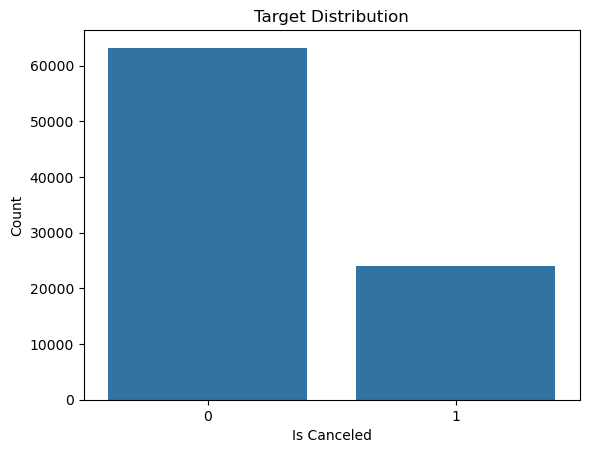

In [23]:
sns.barplot(x = TD.index, y= TD.values)
plt.title("Target Distribution")
plt.ylabel("Count")
plt.xlabel("Is Canceled")
plt.show()

### 6.2 Cancellation by Hotel
    City hotel had more canceled bookings than resort hotel. City hotel had 15,860 cancellations, while resort hotel had 7,890 cancellations.

In [24]:
CH = df[df['is_canceled'] == 1].groupby('hotel')['is_canceled'].count()

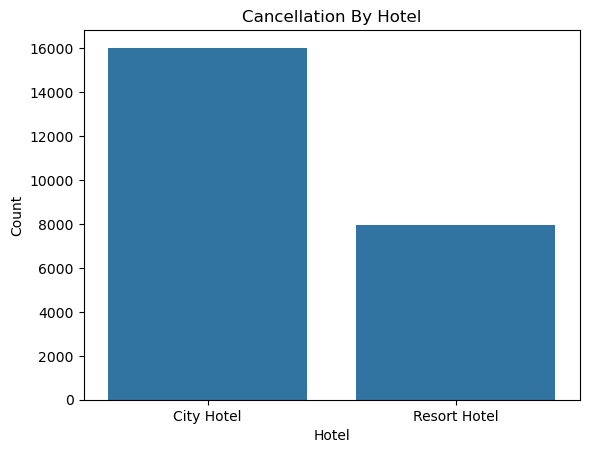

In [25]:
sns.barplot(x = CH.index, y= CH.values)
plt.title("Cancellation By Hotel")
plt.xlabel("Hotel")
plt.ylabel("Count")
plt.show()

### 6.3 Cancellation vs Lead Time
    Customers who canceled their bookings had a higher average lead time (105 days) compared to customers who did not cancel (70 days).This shows that bookings made further in advance were more likely to be canceled.

In [26]:
cl = df.groupby('is_canceled')['lead_time'].mean()

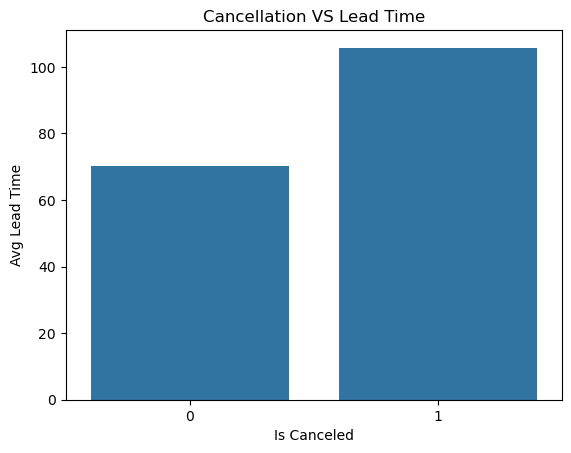

In [27]:
sns.barplot(x= cl.index, y= cl.values )
plt.title("Cancellation VS Lead Time")
plt.xlabel("Is Canceled")
plt.ylabel("Avg Lead Time")
plt.show()

### 6.4 Cancellation by Market Segment
    Online TA had the highest number of canceled bookings, with 18,126 cancellations. Offline TA/TO had 2,012 cancellations, while other segments had fewer cancellations.

In [28]:
cms = df[df['is_canceled'] == 1].groupby('market_segment')['is_canceled'].count()

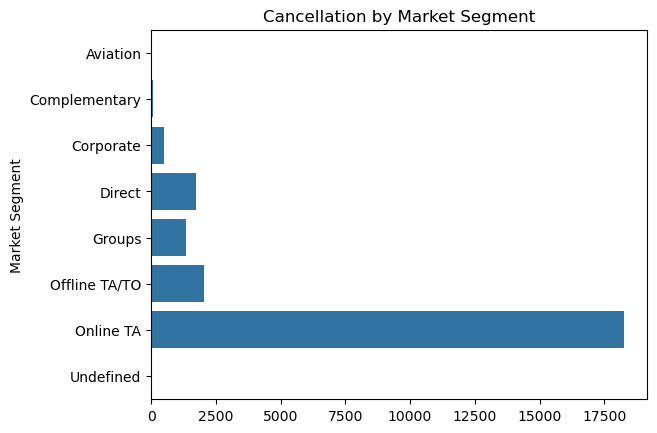

In [29]:
sns.barplot(x= cms.values, y= cms.index)
plt.title("Cancellation by Market Segment")
plt.ylabel("Market Segment")
plt.show()

### 6.5 Cancellation by Deposit Type
    Most canceled bookings had no deposit. No deposit had 22,762 cancellations, while Non refund had 962 and Refundable had only 26 cancellations.

In [30]:
cd = df[df['is_canceled'] == 1].groupby("deposit_type")['is_canceled'].count()
cd

deposit_type
No Deposit    23000
Non Refund      983
Refundable       26
Name: is_canceled, dtype: int64

Text(0.5, 0, 'Deposit Type')

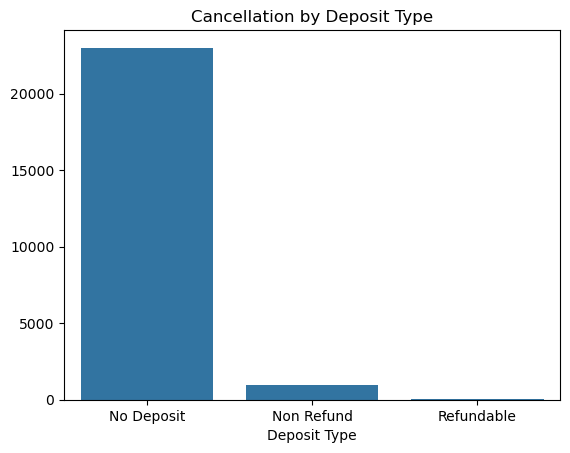

In [31]:
sns.barplot(x= cd.index, y= cd.values)
plt.title("Cancellation by Deposit Type")
plt.xlabel("Deposit Type")

### 6.6 Cancellation by Customer Type 
    Transient customers had the highest number of canceled bookings, with 21,530 cancellations. Transient-party had 1,656, contract had 511, and Group had 53 cancellations.

In [37]:
cct = df[df['is_canceled'] == 1].groupby(by="customer_type").agg({"is_canceled":"count"})
cct

,is_canceled
customer_type,
Contract,511
Group,53
Transient,21530
Transient-Party,1656


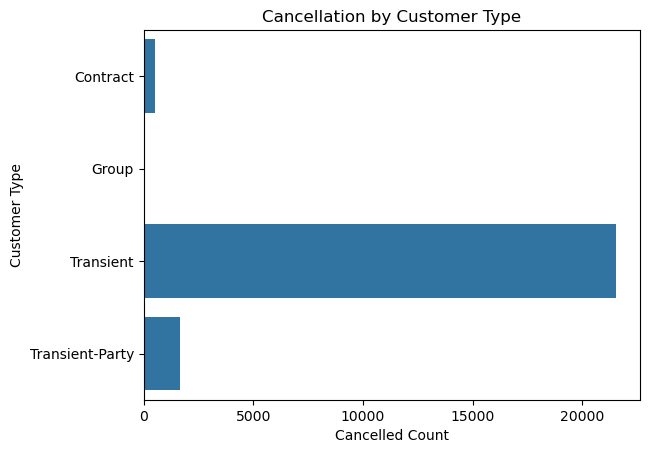

In [47]:
sns.barplot(x="is_canceled", y="customer_type", data=cct)
plt.title("Cancellation by Customer Type")
plt.xlabel("Cancelled Count")
plt.ylabel("Customer Type")
plt.show()

### 6.7 Cancellation by Distribution Channel
    TA/TO had the highest number of canceled bookings, with 21,173 cancellations.Direct bookings had 1,906 cancellations, while the other channels had much fewer cancellations.

In [54]:
cdc = df[df['is_canceled'] == 1].groupby(by='distribution_channel').agg({"is_canceled":"count"}).sort_values("is_canceled", ascending=False)
cdc

,is_canceled
distribution_channel,
TA/TO,21173
Direct,1906
Corporate,633
GDS,34
Undefined,4


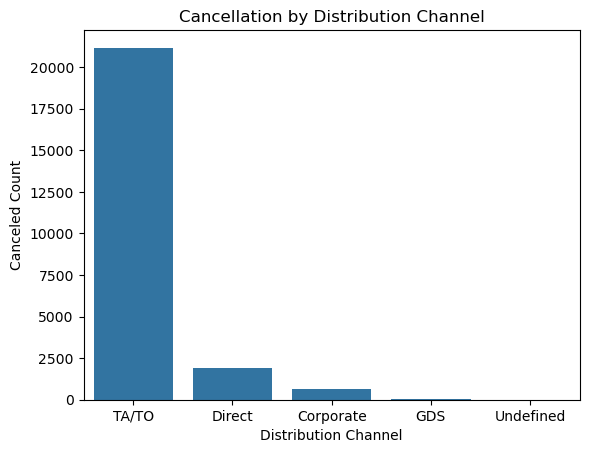

In [56]:
sns.barplot(x= 'distribution_channel', y= 'is_canceled', data=cdc)
plt.title("Cancellation by Distribution Channel")
plt.xlabel("Distribution Channel")
plt.ylabel("Canceled Count")
plt.show()

### 6.8 Guest Composition of Canceled Bookingss

In [63]:
gc = df[df['is_canceled'] == 1][['adults', 'children', 'babies']].mean()

<Axes: xlabel='None'>

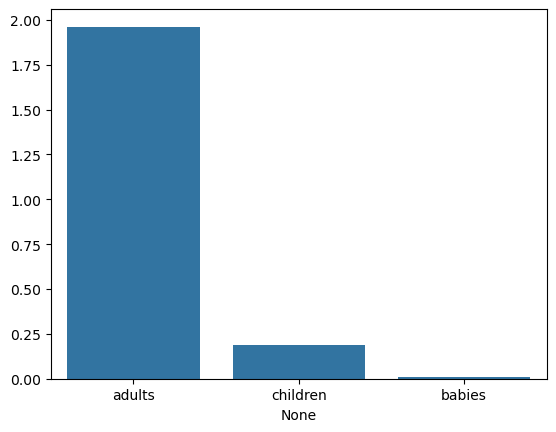

In [64]:
sns.barplot(x= gc.index, y= gc.values)

### 6.9 Cancellation vs Stay Duration
    Canceled bookings had an average stay of about 4.01 nights, while non-canceled bookings had an avg stay of about 3.48 nights.This shows that canceled bookings had a slightly longer average stay.

In [68]:
df["total_nights"] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

In [72]:
csd = df.groupby('is_canceled')['total_nights'].mean()
csd

is_canceled
0    3.484299
1    4.012800
Name: total_nights, dtype: float64

Text(0, 0.5, 'Avg Total Nights')

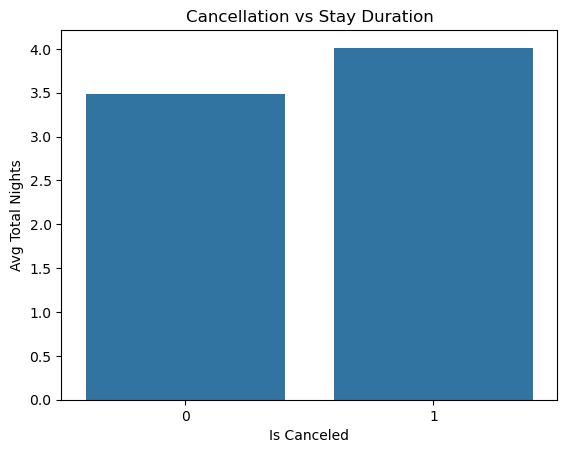

In [74]:
sns.barplot(x= csd.index, y= csd.values)
plt.title("Cancellation vs Stay Duration")
plt.xlabel("Is Canceled")
plt.ylabel("Avg Total Nights")

### 6.10 Correlation Analysis
    The boxplot shows some outliers in lead time, adr, total nights, and number of adults.These values may represent genuine hotel bookings, so they were not removed automatically. Only clearly invalid, such as negative adr, were removed during data cleaning.

In [76]:
corr = df[['is_canceled', 'lead_time', 'total_nights', 'adr', 'booking_changes', 'previous_cancellations', 'previous_bookings_not_canceled', 'total_of_special_requests']].corr()

In [77]:
corr['is_canceled'].sort_values(ascending=False)

is_canceled                       1.000000
lead_time                         0.182493
adr                               0.128588
total_nights                      0.085931
previous_cancellations            0.050931
previous_bookings_not_canceled   -0.051868
booking_changes                  -0.092277
total_of_special_requests        -0.118850
Name: is_canceled, dtype: float64

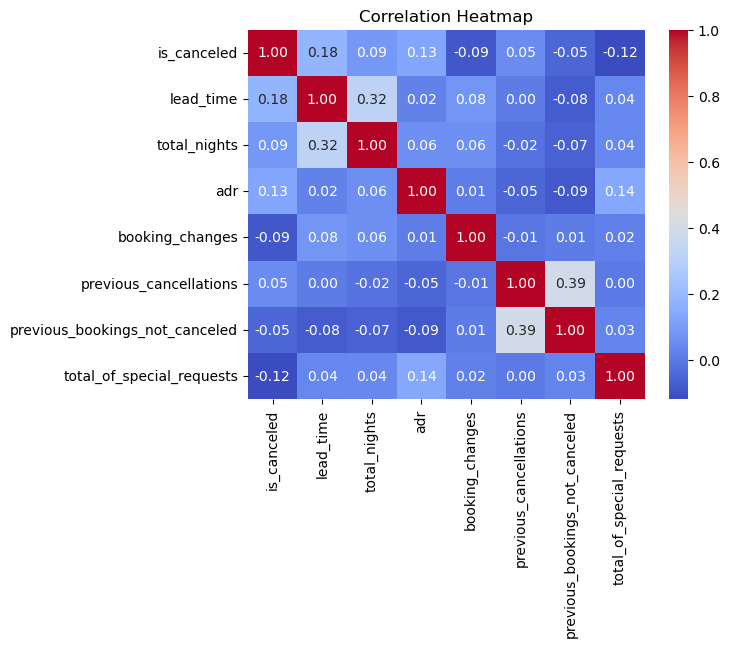

In [79]:
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()

### 6.11 Outlier Analysis

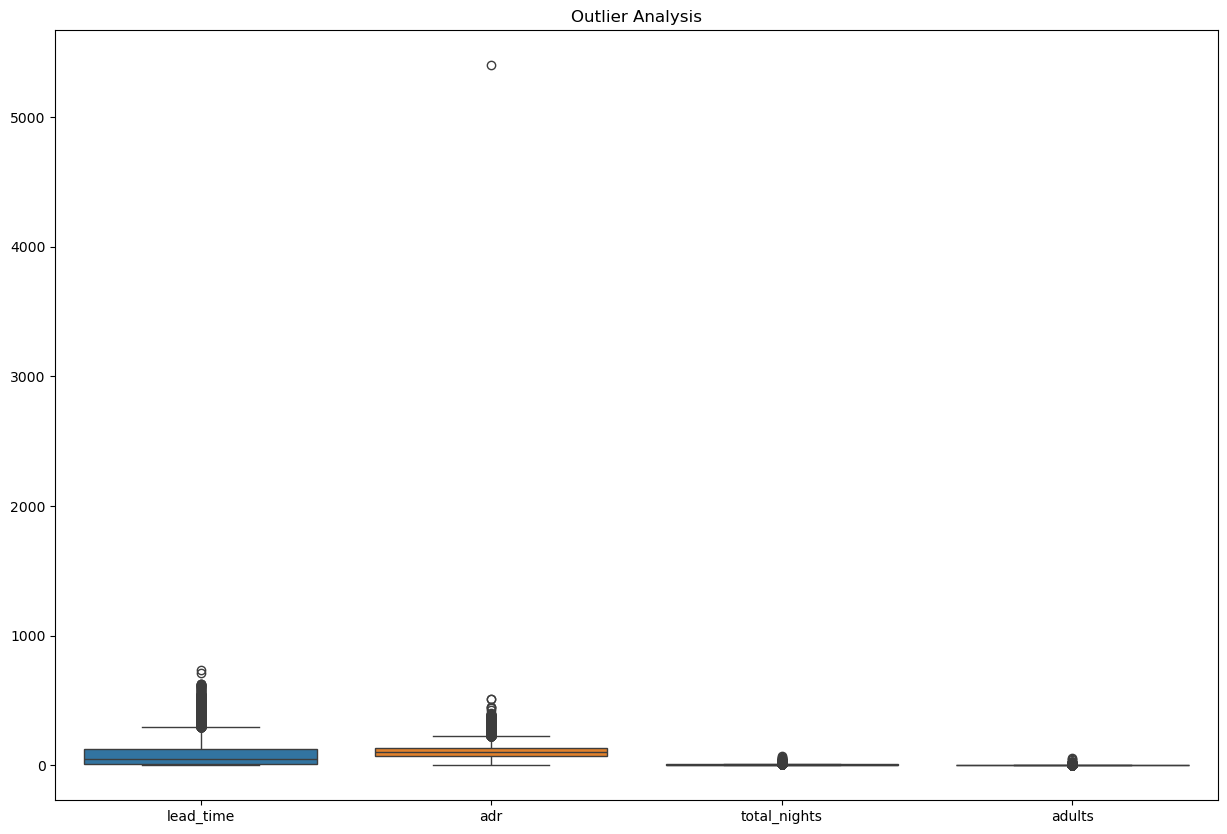

In [94]:
plt.figure(figsize=(15, 10))
sns.boxplot(df[['lead_time', 'adr', 'total_nights', 'adults']])
plt.title("Outlier Analysis")
plt.show()